In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load in raw data

In [2]:
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"

adata_raw = sc.read_h5ad(path)
adata_raw

AnnData object with n_obs × n_vars = 19858 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

In [3]:
### --- Handle HYB cells with NaN feature barcode predictions ---
init_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs

# remove HYB cells with NaN feature barcode predictions
hybrid_to_remove = (adata_raw.obs['dataset'] == 'Hybrid') & (adata_raw.obs['assigned_condition'].isna())
cells_to_keep = ~(hybrid_to_remove)
adata_raw = adata_raw[cells_to_keep].copy()

final_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs
removed_hybrid_cells = init_cells_hybrid - final_cells_hybrid

print(f"Removed {removed_hybrid_cells} 'Hybrid' cells with unassigned feature barcodes")
print(f"Final shape: {adata_raw.shape}")

Removed 1 'Hybrid' cells with unassigned feature barcodes
Final shape: (19857, 28702)


In [4]:
adata_raw.obs['dataset'].value_counts()

dataset
Hybrid     10894
Control     8963
Name: count, dtype: int64

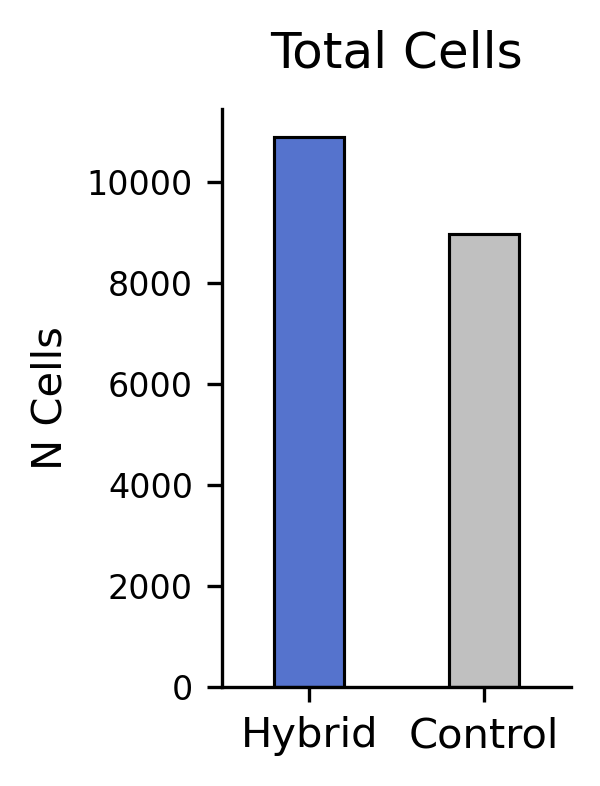

In [6]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.5, 2.5
fig, axs = plt.subplots()

dataset_colors = ["royalblue", "silver"]

sns.countplot(data=adata_raw.obs,
            x='dataset',
            hue='dataset',
            width=0.4,
            ec='k',
            linewidth=0.75,
            palette=dataset_colors,
           )

plt.ylabel("N Cells")
plt.xlabel("")

plt.title("Total Cells", pad=10)

plt.yticks(fontsize=8)

sns.despine()
plt.show()

In [7]:
nonzero_matrix = adata_raw.X > 0

# Create a Series that maps each observation to its dataset
datasets = adata_raw.obs['dataset']

# Convert to DataFrame for grouping
nonzero_df = pd.DataFrame(nonzero_matrix.toarray() if hasattr(nonzero_matrix, "toarray") else nonzero_matrix,
                          index=adata_raw.obs_names,
                          columns=adata_raw.var_names)
nonzero_df['dataset'] = datasets.values

# Group by dataset and count number of genes (columns) with any non-zero value
genes_detected = nonzero_df.groupby('dataset', observed=True).apply(lambda x: (x.drop(columns='dataset').sum(axis=0) > 0).sum())

print(f"Number of non-zero genes:\n {genes_detected}\n")

Number of non-zero genes:
 dataset
Hybrid     27819
Control    23635
dtype: int64



/tmp/ipykernel_114680/1058828917.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genes_detected = nonzero_df.groupby('dataset', observed=True).apply(lambda x: (x.drop(columns='dataset').sum(axis=0) > 0).sum())


In [8]:
print(f"Median read depth: \n{adata_raw.obs.groupby('dataset', observed=True)['total_reads'].median()}")
adata_raw.obs.groupby('dataset', observed=True)['total_reads'].describe()

Median read depth: 
dataset
Hybrid     11731.0
Control    12844.0
Name: total_reads, dtype: float32


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
Hybrid,10894.0,11572.786133,5878.607422,10.0,8176.75,11731.0,15014.25,46373.0
Control,8963.0,11848.504883,6289.082520,18.0,8830.50,12844.0,16045.00,35831.0


In [9]:
print(f"Median genes per cell: \n{adata_raw.obs.groupby('dataset', observed=True)['total_genes'].median()}")
adata_raw.obs.groupby('dataset', observed=True)['total_genes'].describe()

Median genes per cell: 
dataset
Hybrid     3786.0
Control    3405.0
Name: total_genes, dtype: float64


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
Hybrid,10894.0,3588.252800,1308.280742,10.0,3139.0,3786.0,4359.0,7957.0
Control,8963.0,3036.596006,1428.829430,18.0,2655.5,3405.0,3998.0,6078.0


In [10]:
gene_counts = np.asarray(adata_raw.X.sum(axis=0)).ravel()

### total counts per gene 
adata_raw.var['total_counts'] = gene_counts

adata_raw.var['total_counts'].describe()

count    2.870200e+04
mean     8.092541e+03
std      6.247444e+04
min      1.000000e+00
25%      4.400000e+01
50%      4.210000e+02
75%      3.500500e+03
max      4.942973e+06
Name: total_counts, dtype: float64

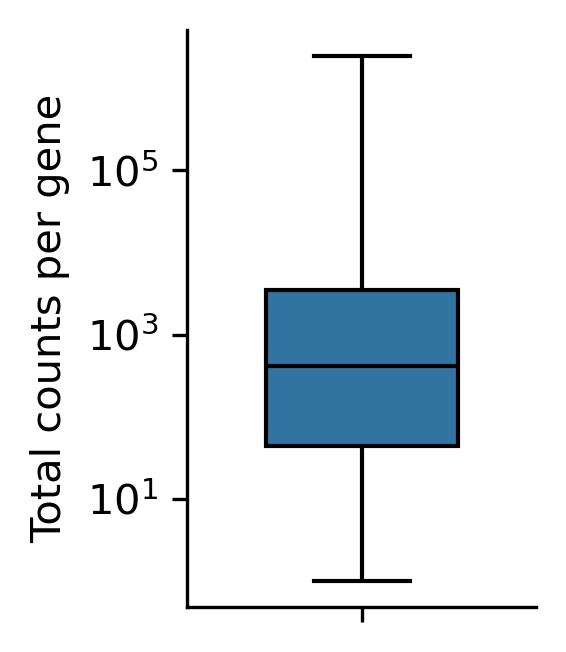

In [11]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.5, 2.5
fig, axs = plt.subplots()

sns.boxplot(
    adata_raw.var['total_counts'],
    width=0.55,
    showfliers=False,
    linecolor='k',
    log_scale=True,
    #showcaps=False,
)

plt.ylabel("Total counts per gene")

sns.despine()
plt.show()

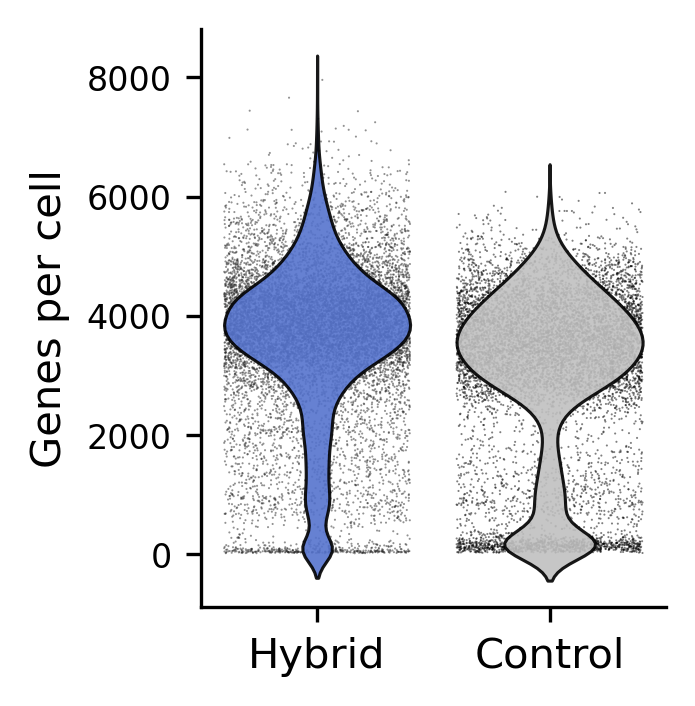

In [12]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 2.5
fig, axs = plt.subplots()

dataset_colors = ["royalblue", "silver"]

ax = sns.violinplot(
    data=adata_raw.obs,
    x='dataset',
    y='total_genes',
    hue='dataset',
    linewidth=0.75,
    linecolor='k',
    palette=dataset_colors,
    inner=None,
    alpha=0.9,
    zorder=1,
)

sns.stripplot(
    data=adata_raw.obs,
    x='dataset',
    y='total_genes',
    hue='dataset',
    jitter=0.4, 
    palette='dark:black',
    edgecolor=None,
    size=0.5,       
    alpha=0.5,    
    ax=ax,        
    legend=False,
    zorder=0,
)

plt.ylabel("Genes per cell")
plt.xlabel("")
plt.yticks(fontsize=8)
sns.despine()
plt.show()

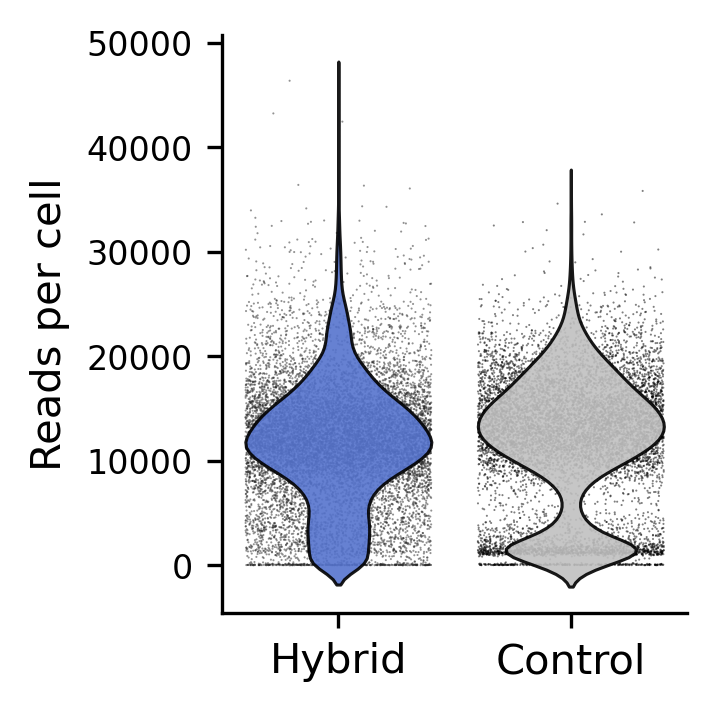

In [16]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 2.5
fig, axs = plt.subplots()

dataset_colors = ["royalblue", "silver"]

ax = sns.violinplot(
    data=adata_raw.obs,
    x='dataset',
    y='total_reads',
    hue='dataset',
    linewidth=0.75,
    linecolor='k',
    palette=dataset_colors,
    inner=None,
    alpha=0.9,
    zorder=1,
)

sns.stripplot(
    data=adata_raw.obs,
    x='dataset',
    y='total_reads',
    hue='dataset',
    jitter=0.4, 
    palette='dark:black',
    edgecolor=None,
    size=0.5,       
    alpha=0.5,    
    ax=ax,        
    legend=False,
    zorder=0,
)

plt.ylabel("Reads per cell")
plt.xlabel("")
plt.yticks(fontsize=8)
sns.despine()
plt.show()

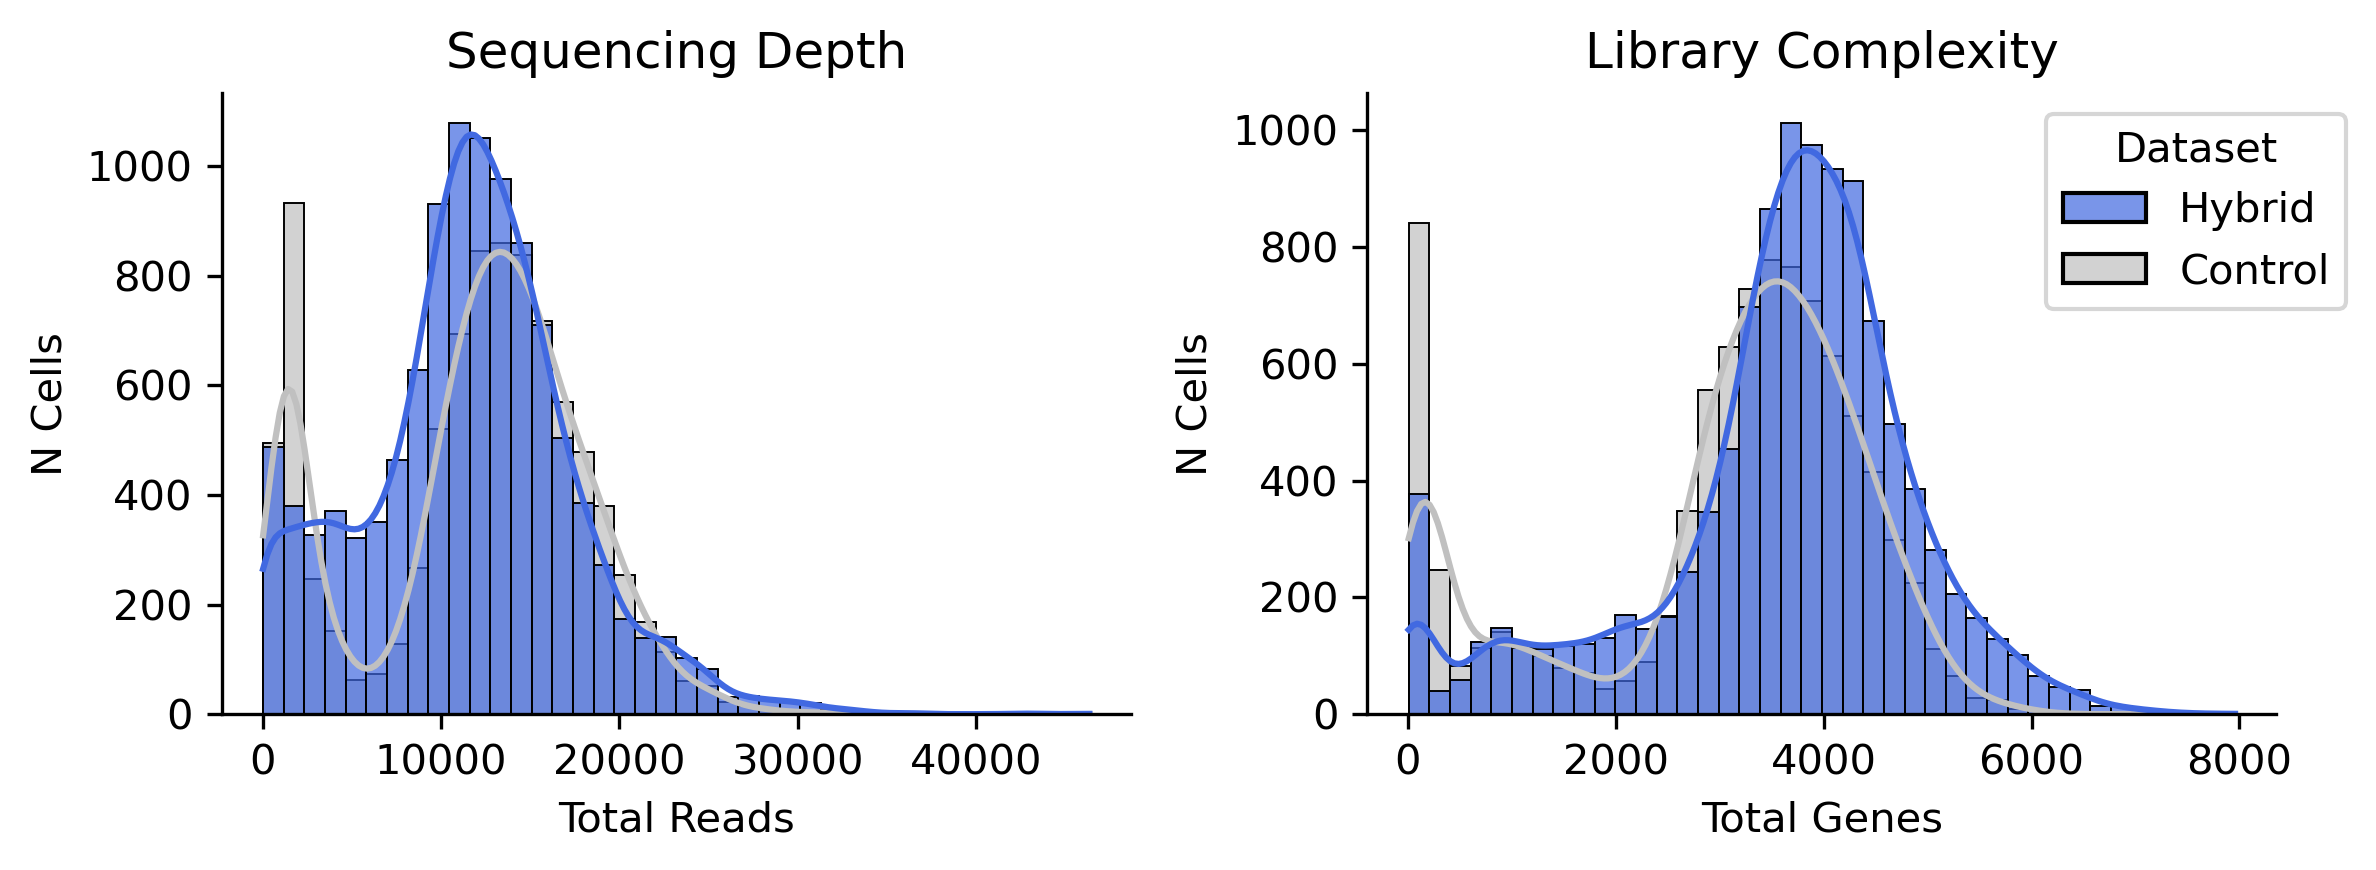

In [15]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, 3
fig, axs = plt.subplots(1, 2)

sns.histplot(data=adata_raw.obs, x=adata_raw.obs['total_reads'], hue=adata_raw.obs['dataset'],
             palette=dataset_colors, bins=40, kde=True, ax=axs[0], legend=False, alpha=0.7)

axs[0].set_ylabel("N Cells")
axs[0].set_xlabel("Total Reads")
axs[0].set_title("Sequencing Depth")


sns.histplot(data=adata_raw.obs, x=adata_raw.obs['total_genes'], hue=adata_raw.obs['dataset'],
             palette=dataset_colors, bins=40, kde=True, ax=axs[1], alpha=0.7)

axs[1].set_ylabel("N Cells")
axs[1].set_xlabel("Total Genes")
axs[1].set_title("Library Complexity")

sns.move_legend(plt.gca(), loc='upper right', title='Dataset', bbox_to_anchor=(1.1, 1))

sns.despine()
plt.tight_layout()
plt.show()

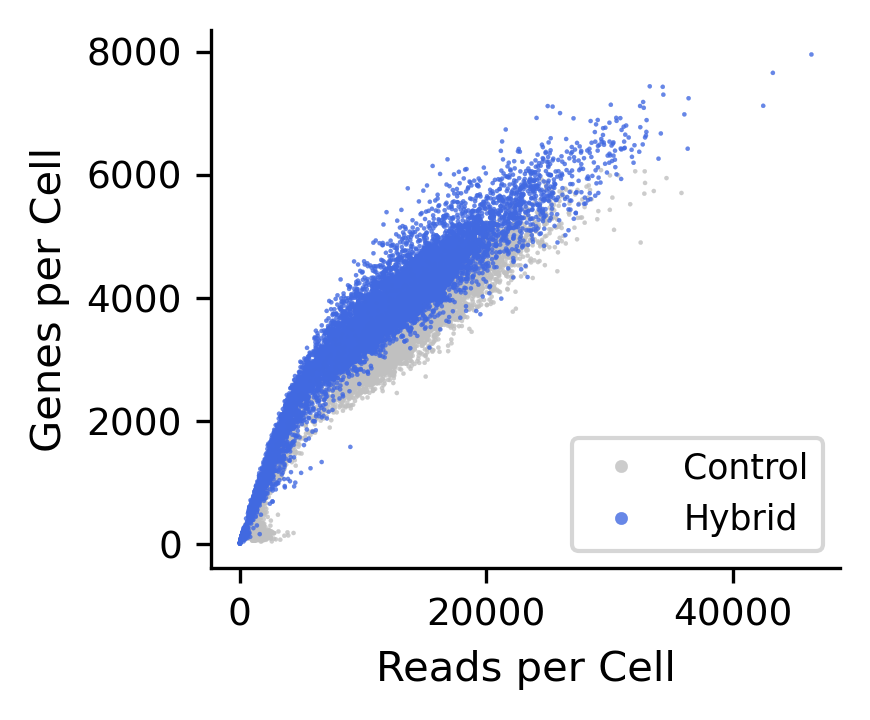

In [19]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 2.5

df = adata_raw.obs[['total_reads', 'total_genes', 'dataset']].copy()
df = df.sort_values(by='dataset', ascending=False)

dataset_colors = ["silver", "royalblue"]

sns.scatterplot(data=df,
                x='total_reads',
                y='total_genes',
                hue='dataset',
                hue_order=['Control', 'Hybrid'],
                palette=dataset_colors,
                s=1,
                edgecolor=None,
                alpha=0.8,
               )

sns.move_legend(plt.gca(), loc='lower right', fontsize='small', markerscale=3, title="")#, bbox_to_anchor=(1.1, 1))

plt.ylabel("Genes per Cell")
plt.xlabel("Reads per Cell")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# Demultiplexing stats

In [6]:
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/pipeline_outputs/hyb_epi2me_final/hybrid/hybrid.bc_assignment_summary.tsv"

df = pd.read_csv(path, header=None, sep='\t')
print(df.shape)

# df[1] = df[1].astype(int)
# pd.set_option("display.float_format", "{:,}".format) 

df

(10, 2)


,0,1
0,bc_corrected,"16,060,051.0"
1,bc_no_shortlist_match,"21,859,986.0"
2,bc_shortlist_exact_match,"140,097,427.0"
3,bc_shortlist_multiple_hits,"4,755,279.0"
4,cell_count_read_threshold,"1,068.0"
5,fraction_of_high_q_reads_in_cells,0.94
6,high_q_reads_in_cells,"126,307,883.0"
7,high_quality_barcodes,"715,111.0"
8,high_quality_reads,"134,381,035.0"
9,n_cells_after_filtering,"10,895.0"


In [8]:
df.iloc[0:4, 1].sum()

np.float64(182772743.0)

In [9]:
path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.bc_assignment_summary.tsv"

df = pd.read_csv(path, header=None, sep='\t')
print(df.shape)

# df[1] = df[1].astype(int)
# pd.set_option("display.float_format", "{:,}".format) 

df

(10, 2)


,0,1
0,bc_corrected,"13,319,318.0"
1,bc_no_shortlist_match,"23,136,392.0"
2,bc_shortlist_exact_match,"116,415,772.0"
3,bc_shortlist_multiple_hits,"3,408,885.0"
4,cell_count_read_threshold,931.0
5,fraction_of_high_q_reads_in_cells,0.91
6,high_q_reads_in_cells,"93,257,239.0"
7,high_quality_barcodes,"619,033.0"
8,high_quality_reads,"102,222,758.0"
9,n_cells_after_filtering,"8,963.0"


In [10]:
df.iloc[0:4, 1].sum()

np.float64(156280367.0)